In [35]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [36]:
# Load Dataset

df = pd.read_csv("../data/Retail_Transaction_Dataset.csv")

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

print(df.shape)

df.head()

(100000, 10)


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [37]:
# Customer Feature Engineering

customer_df = (
    df.groupby("CustomerID")
    .agg(
        TotalSpent=("TotalAmount", "sum"),
        TotalTransactions=("TransactionDate", "count"),
        TotalQuantity=("Quantity", "sum"),
        AverageOrderValue=("TotalAmount", "mean"),
        AverageDiscount=("DiscountApplied(%)", "mean"),
        LastPurchase=("TransactionDate", "max")
    )
    .reset_index()
)

reference_date = df["TransactionDate"].max()

customer_df["Recency"] = (
    reference_date - customer_df["LastPurchase"]
).dt.days

customer_df.drop(columns=["LastPurchase"], inplace=True)

customer_df.head()

,CustomerID,TotalSpent,TotalTransactions,TotalQuantity,AverageOrderValue,AverageDiscount,Recency
0,14,256.232791,1,5,256.232791,15.504050,266
1,42,502.656523,1,7,502.656523,19.191090,345
2,49,21.399047,1,1,21.399047,14.923377,328
3,59,249.492696,2,12,124.746348,7.175628,27
4,65,548.006625,1,8,548.006625,8.319811,315


In [38]:
# Prepare Features for Clustering

rfm_features = [
    "Recency",
    "TotalTransactions",
    "TotalSpent"
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    customer_df[rfm_features]
)

In [39]:
# Customer Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(rfm_scaled)

cluster_summary = (
    customer_df
    .groupby("Cluster")[rfm_features]
    .mean()
    .round(2)
)

print(cluster_summary)

         Recency  TotalTransactions  TotalSpent
Cluster                                        
0         273.54               1.00      251.17
1          91.18               1.00      245.76
2         118.53               2.04      503.23


In [40]:
# Validate Clustering

sil_score = silhouette_score(
    rfm_scaled,
    customer_df["Cluster"]
)

print("="*60)
print("Cluster Validation")
print("="*60)

print(f"Silhouette Score : {sil_score:.4f}")

Cluster Validation
Silhouette Score : 0.3930


In [41]:
# Generate Behaviour-Based Churn Labels

cluster_summary = customer_df.groupby("Cluster")[rfm_features].mean()

high_risk_cluster = cluster_summary["Recency"].idxmax()

print(f"High Risk Cluster : {high_risk_cluster}")

customer_df["Churn"] = (
    customer_df["Cluster"] == high_risk_cluster
).astype(int)

print("\nClass Distribution")
print(customer_df["Churn"].value_counts())

High Risk Cluster : 0

Class Distribution
Churn
0    50157
1    45058
Name: count, dtype: int64


In [42]:
# Feature Selection

features = [
    "Recency",
    "TotalTransactions",
    "TotalSpent"
]

X = customer_df[features]

y = customer_df["Churn"]

print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (95215, 3)
Target Vector  : (95215,)


In [43]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 76172
Testing Samples  : 19043


In [44]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [45]:
# Predictions

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

In [46]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("="*60)
print("Random Forest Model Evaluation")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

Random Forest Model Evaluation
Accuracy  : 0.9999
Precision : 1.0000
Recall    : 0.9999
F1 Score  : 0.9999
ROC-AUC   : 1.0000


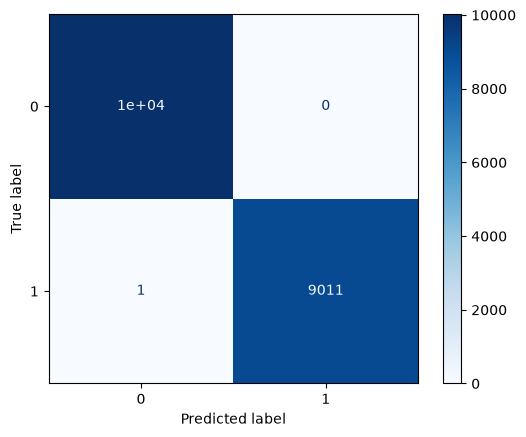


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10031
           1       1.00      1.00      1.00      9012

    accuracy                           1.00     19043
   macro avg       1.00      1.00      1.00     19043
weighted avg       1.00      1.00      1.00     19043



In [47]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.show()

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

In [48]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Recency,0.949405
1,TotalTransactions,0.042794
2,TotalSpent,0.007801


In [49]:
# Save Improved Customer Churn Dataset

customer_df.to_csv(
    "../data/improved_customer_churn.csv",
    index=False
)

print("="*60)
print("Improved Customer Churn Dataset Saved Successfully")
print("="*60)
print("Saved As:")
print("../data/improved_customer_churn.csv")

Improved Customer Churn Dataset Saved Successfully
Saved As:
../data/improved_customer_churn.csv


In [50]:
import joblib

joblib.dump(
    rf_model,
    "../models/improved_customer_churn.pkl"
)

print("="*60)
print("Random Forest Model Saved Successfully")
print("="*60)
print("Saved As:")
print("../models/improved_customer_churn.pkl")

Random Forest Model Saved Successfully
Saved As:
../models/improved_customer_churn.pkl
